
# EduGuardian AI - Exploratory Data Analysis & Model Selection
## ICT304 | Murdoch University | T1 2026  
**Project:** AI Academic Risk Prediction & Early Intervention System  
**System Name:** Early Academic Risk Prediction Engine  
**Team:** Rohit Kumar Malik | Izaan Shumaiz | Mohamed Sinan  
**Supervisor:** Mr. Karim Tout  

---

## Notebook Purpose

This notebook documents the **EDA, feature inspection, class balancing, model comparison, and final model selection process** used in the EduGuardian AI system.

It is aligned to the current project codebase and folder structure:

- `src/preprocess.py`
- `src/train_model.py`
- `src/evaluate_model.py`
- `src/predict.py`
- `src/risk_engine.py`

### What this notebook covers

1. Raw dataset discovery and structure inspection  
2. Unified schema and processed training files  
3. Class distribution before and after SMOTE  
4. Feature distributions and outlier patterns  
5. Missingness and cross-dataset coverage  
6. Correlation and feature relationships  
7. Model comparison using saved metrics  
8. Threshold sensitivity and held-out validation  
9. Final model selection justification  


In [1]:

import os
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Project path setup
# ------------------------------------------------------------
# Expected notebook location:
#   ICT304_FinalProject/notebooks/EDA_and_Model_Selection.ipynb
# ------------------------------------------------------------
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR      = PROJECT_ROOT / "data"
RAW_DIR       = DATA_DIR / "raw"
PROC_DIR      = DATA_DIR / "processed"
MODELS_DIR    = PROJECT_ROOT / "models"
REPORTS_DIR   = PROJECT_ROOT / "reports"
PLOTS_DIR     = REPORTS_DIR / "plots"

RAW_DS1 = RAW_DIR / "Dataset1_StudentsGrading" / "Students_Grading_Dataset_Biased.csv"
RAW_DS2 = RAW_DIR / "Dataset2_StudentPerformancePrediction" / "student_performance_dataset.csv"
RAW_DS3 = RAW_DIR / "Dataset3_StudentPerformanceFactors" / "StudentPerformanceFactors.csv"
RAW_DS4 = RAW_DIR / "Dataset4_StudentQuizMarks" / "marks_final.csv"
RAW_DS5_INFO = RAW_DIR / "Dataset5_OULAD" / "studentInfo.csv"
RAW_DS5_ASSESS = RAW_DIR / "Dataset5_OULAD" / "studentAssessment.csv"
RAW_DS5_ASSESS_META = RAW_DIR / "Dataset5_OULAD" / "assessments.csv"

MERGED_FILE   = PROC_DIR / "merged_training_data.csv"
TRAIN_FILE    = PROC_DIR / "ds1_train_smote.csv"
VALID_FILE    = PROC_DIR / "ds5_validation.csv"

MODEL_METRICS = MODELS_DIR / "model_metrics.json"

FINAL_FEATURES = [
    "Quizzes_Avg",
    "Assignments_Avg",
    "Midterm_Score",
    "Participation_Score",
    "Projects_Score",
]
TARGET_COL = "At_Risk"

COLORS = {
    "high": "#C8102E",
    "low": "#10B981",
    "amber": "#F59E0B",
    "blue": "#2563EB",
    "gray": "#6B7280",
    "bg": "#F8FAFC",
}

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
sns.set_theme(style="whitegrid")

print("Project root:", PROJECT_ROOT)
print("Processed data directory exists:", PROC_DIR.exists())
print("Models directory exists:", MODELS_DIR.exists())


Project root: d:\ICT 304\Assignment\Assignment 2\ICT304_FinalProject
Processed data directory exists: True
Models directory exists: True


## 1. File Discovery and Project Data Inventory

In [2]:

inventory = {
    "DS1 - Students Grading (Biased)": RAW_DS1,
    "DS2 - Student Performance Prediction": RAW_DS2,
    "DS3 - Student Performance Factors": RAW_DS3,
    "DS4 - Student Quiz Marks": RAW_DS4,
    "DS5 - OULAD studentInfo": RAW_DS5_INFO,
    "DS5 - OULAD studentAssessment": RAW_DS5_ASSESS,
    "DS5 - OULAD assessments": RAW_DS5_ASSESS_META,
    "Processed - merged_training_data.csv": MERGED_FILE,
    "Processed - ds1_train_smote.csv": TRAIN_FILE,
    "Processed - ds5_validation.csv": VALID_FILE,
    "Models - model_metrics.json": MODEL_METRICS,
}

rows = []
for name, path in inventory.items():
    rows.append({
        "Resource": name,
        "Exists": path.exists(),
        "Path": str(path.relative_to(PROJECT_ROOT)) if path.exists() else str(path.relative_to(PROJECT_ROOT)),
        "Size_KB": round(path.stat().st_size / 1024, 1) if path.exists() else np.nan,
    })

inventory_df = pd.DataFrame(rows)
inventory_df


,Resource,Exists,Path,Size_KB
0,DS1 - Students Grading (Biased),True,data\raw\Dataset1_StudentsGrading\Students_Gra...,683.6
1,DS2 - Student Performance Prediction,True,data\raw\Dataset2_StudentPerformancePrediction...,40.7
2,DS3 - Student Performance Factors,True,data\raw\Dataset3_StudentPerformanceFactors\St...,626.9
3,DS4 - Student Quiz Marks,True,data\raw\Dataset4_StudentQuizMarks\marks_final...,48.8
4,DS5 - OULAD studentInfo,True,data\raw\Dataset5_OULAD\studentInfo.csv,3380.5
5,DS5 - OULAD studentAssessment,True,data\raw\Dataset5_OULAD\studentAssessment.csv,5556.9
6,DS5 - OULAD assessments,True,data\raw\Dataset5_OULAD\assessments.csv,8.0
7,Processed - merged_training_data.csv,True,data\processed\merged_training_data.csv,512.9
8,Processed - ds1_train_smote.csv,True,data\processed\ds1_train_smote.csv,2402.9
9,Processed - ds5_validation.csv,True,data\processed\ds5_validation.csv,1334.9


## 2. Raw Dataset Structure Inspection

In [3]:

def inspect_csv(path: Path, name: str, nrows: int = 5):
    if not path.exists():
        print(f"[MISSING] {name}: {path}")
        return None

    df = pd.read_csv(path)
    preview = df.head(nrows)

    print("=" * 90)
    print(name)
    print("=" * 90)
    print(f"Shape        : {df.shape}")
    print(f"Columns ({len(df.columns)}): {list(df.columns)}")
    print("\nDtypes:")
    print(df.dtypes.to_string())
    print("\nPreview:")
    display(preview)
    return df

raw_frames = {}
for name, path in [
    ("DS1 - Students Grading (Biased)", RAW_DS1),
    ("DS2 - Student Performance Prediction", RAW_DS2),
    ("DS3 - Student Performance Factors", RAW_DS3),
    ("DS4 - Student Quiz Marks", RAW_DS4),
    ("DS5 - OULAD studentInfo", RAW_DS5_INFO),
]:
    raw_frames[name] = inspect_csv(path, name)


DS1 - Students Grading (Biased)
Shape        : (5000, 23)
Columns (23): ['Student_ID', 'First_Name', 'Last_Name', 'Email', 'Gender', 'Age', 'Department', 'Attendance (%)', 'Midterm_Score', 'Final_Score', 'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score', 'Projects_Score', 'Total_Score', 'Grade', 'Study_Hours_per_Week', 'Extracurricular_Activities', 'Internet_Access_at_Home', 'Parent_Education_Level', 'Family_Income_Level', 'Stress_Level (1-10)', 'Sleep_Hours_per_Night']

Dtypes:
Student_ID                     object
First_Name                     object
Last_Name                      object
Email                          object
Gender                         object
Age                             int64
Department                     object
Attendance (%)                float64
Midterm_Score                 float64
Final_Score                   float64
Assignments_Avg               float64
Quizzes_Avg                   float64
Participation_Score           float64
Projects_Score  

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0@university.com,Female,22,Engineering,52.29,55.03,57.82,...,85.90,56.09,F,6.2,No,Yes,High School,Medium,5,4.7
1,S1001,Maria,Brown,student1@university.com,Male,18,Engineering,97.27,97.23,45.80,...,55.65,50.64,A,19.0,No,Yes,NaN,Medium,4,9.0
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Business,57.19,67.05,93.68,...,73.79,70.30,D,20.7,No,Yes,Master's,Low,6,6.2
3,S1003,Omar,Williams,student3@university.com,Female,24,Mathematics,95.15,47.79,80.63,...,92.12,61.63,A,24.8,Yes,Yes,High School,High,3,6.7
4,S1004,John,Smith,student4@university.com,Female,23,CS,54.18,46.59,78.89,...,68.42,66.13,F,15.4,Yes,Yes,High School,High,2,7.1


DS2 - Student Performance Prediction
Shape        : (708, 10)
Columns (10): ['Student_ID', 'Gender', 'Study_Hours_per_Week', 'Attendance_Rate', 'Past_Exam_Scores', 'Parental_Education_Level', 'Internet_Access_at_Home', 'Extracurricular_Activities', 'Final_Exam_Score', 'Pass_Fail']

Dtypes:
Student_ID                     object
Gender                         object
Study_Hours_per_Week            int64
Attendance_Rate               float64
Past_Exam_Scores                int64
Parental_Education_Level       object
Internet_Access_at_Home        object
Extracurricular_Activities     object
Final_Exam_Score                int64
Pass_Fail                      object

Preview:


,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,S147,Male,31,68.267841,86,High School,Yes,Yes,63,Pass
1,S136,Male,16,78.222927,73,PhD,No,No,50,Fail
2,S209,Female,21,87.525096,74,PhD,Yes,No,55,Fail
3,S458,Female,27,92.076483,99,Bachelors,No,No,65,Pass
4,S078,Female,37,98.655517,63,Masters,No,Yes,70,Pass


DS3 - Student Performance Factors
Shape        : (6607, 20)
Columns (20): ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']

Dtypes:
Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physica

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


DS4 - Student Quiz Marks
Shape        : (1053, 16)
Columns (16): ['SNO.', 'ROLL NUMBER', 'Q1 (5)', 'Q2 (5)', 'Q3 (5)', 'Q4 (5)', 'Q5 (5)', 'Q6 (5)', 'Q7 (5)', 'Q8 (5)', 'Q9 (5)', 'Q10 (5)', 'Q11 (5)', 'Q12 (5)', 'Top 9 (out of 45)', 'Out of 30']

Dtypes:
SNO.                   int64
ROLL NUMBER            int64
Q1 (5)                object
Q2 (5)                object
Q3 (5)                object
Q4 (5)                object
Q5 (5)                object
Q6 (5)                object
Q7 (5)                object
Q8 (5)                object
Q9 (5)                object
Q10 (5)               object
Q11 (5)               object
Q12 (5)               object
Top 9 (out of 45)      int64
Out of 30            float64

Preview:


,SNO.,ROLL NUMBER,Q1 (5),Q2 (5),Q3 (5),Q4 (5),Q5 (5),Q6 (5),Q7 (5),Q8 (5),Q9 (5),Q10 (5),Q11 (5),Q12 (5),Top 9 (out of 45),Out of 30
0,1,102003733,AB,AB,AB,AB,AB,AB,3,5,AB,AB,AB,4,12,8.0
1,2,102203002,5,AB,4,4,4,4,4,3,5,5,5,3,40,26.7
2,3,102203003,5,4,4,4,4,5,4,3,4,5,4,2,39,26.0
3,4,102203005,AB,AB,AB,AB,3,5,3,4,4,5,5,AB,29,19.3
4,5,102203007,AB,AB,AB,5,4,3,3,5,3,5,5,3,36,24.0


DS5 - OULAD studentInfo
Shape        : (32593, 12)
Columns (12): ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']

Dtypes:
code_module             object
code_presentation       object
id_student               int64
gender                  object
region                  object
highest_education       object
imd_band                object
age_band                object
num_of_prev_attempts     int64
studied_credits          int64
disability              object
final_result            object

Preview:


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass



## 3. Processed Dataset Inspection

The current preprocessing pipeline generates three key files:

- `merged_training_data.csv` - combined DS1–DS4 training pool before SMOTE  
- `ds1_train_smote.csv` - balanced training data after SMOTE  
- `ds5_validation.csv` - held-out OULAD validation data  

These files reflect the latest system design in `src/preprocess.py`.


In [4]:

processed_views = {}
for name, path in [
    ("Merged training data", MERGED_FILE),
    ("SMOTE-balanced training data", TRAIN_FILE),
    ("Held-out DS5 validation", VALID_FILE),
]:
    if path.exists():
        df = pd.read_csv(path)
        processed_views[name] = df
        print("=" * 90)
        print(name)
        print("=" * 90)
        print("Shape:", df.shape)
        print("Columns:", list(df.columns))
        display(df.head())
    else:
        print(f"[MISSING] {name}: {path}")


Merged training data
Shape: (13368, 7)
Columns: ['Midterm_Score', 'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score', 'Projects_Score', 'At_Risk', 'source']


,Midterm_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,At_Risk,source
0,55.03,84.22,74.06,39.9,85.90,1,DS1
1,97.23,74.81,94.24,83.2,55.65,0,DS1
2,67.05,67.70,85.70,50.5,73.79,0,DS1
3,47.79,66.06,93.51,65.4,92.12,0,DS1
4,46.59,96.85,83.70,59.7,68.42,1,DS1


SMOTE-balanced training data
Shape: (24170, 6)
Columns: ['Quizzes_Avg', 'Assignments_Avg', 'Midterm_Score', 'Participation_Score', 'Projects_Score', 'At_Risk']


,Quizzes_Avg,Assignments_Avg,Midterm_Score,Participation_Score,Projects_Score,At_Risk
0,0.020547,1.064282,-1.221023,-0.487299,0.745420,1
1,1.347657,0.281234,1.710248,1.662442,-1.585099,0
2,0.786035,-0.310421,-0.386097,0.038966,-0.187558,0
3,1.299649,-0.446893,-1.723924,0.778715,1.224621,0
4,0.654508,2.115280,-1.807278,0.495724,-0.601273,1


Held-out DS5 validation
Shape: (32593, 6)
Columns: ['At_Risk', 'Quizzes_Avg', 'Assignments_Avg', 'Midterm_Score', 'Participation_Score', 'Projects_Score']


,At_Risk,Quizzes_Avg,Assignments_Avg,Midterm_Score,Participation_Score,Projects_Score
0,0,81.285714,82.000000,50.0,50.0,50.0
1,0,81.285714,66.400000,50.0,50.0,50.0
2,1,81.285714,73.333333,50.0,50.0,50.0
3,0,81.285714,76.000000,50.0,50.0,50.0
4,0,81.285714,54.400000,50.0,50.0,50.0


## 4. Unified Feature Schema Check

In [5]:

schema_rows = []

for name, df in processed_views.items():
    row = {"Dataset": name}
    for feat in FINAL_FEATURES + [TARGET_COL]:
        row[feat] = feat in df.columns
    row["source_column"] = "source" in df.columns
    schema_rows.append(row)

schema_df = pd.DataFrame(schema_rows)
schema_df


,Dataset,Quizzes_Avg,Assignments_Avg,Midterm_Score,Participation_Score,Projects_Score,At_Risk,source_column
0,Merged training data,True,True,True,True,True,True,True
1,SMOTE-balanced training data,True,True,True,True,True,True,False
2,Held-out DS5 validation,True,True,True,True,True,True,False



## 5. Class Distribution Before and After SMOTE

The final training design applies **SMOTE only to the DS1–DS4 training pool** and keeps **DS5 / OULAD** as a separate held-out validation dataset.

This section helps justify:
- why balancing was needed
- how severe the minority-class problem was before SMOTE
- what the balanced training distribution looks like afterward


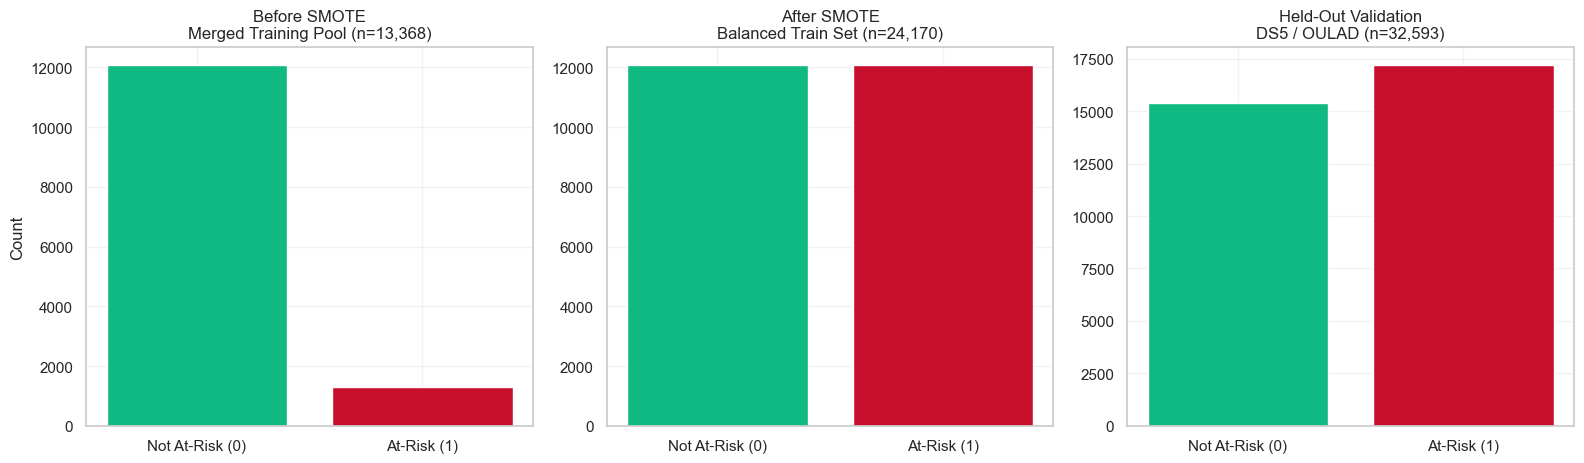

In [6]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# Before SMOTE
if MERGED_FILE.exists():
    df_before = pd.read_csv(MERGED_FILE)
    counts_before = df_before[TARGET_COL].value_counts().sort_index()
    axes[0].bar(["Not At-Risk (0)", "At-Risk (1)"], counts_before.values, color=[COLORS["low"], COLORS["high"]])
    axes[0].set_title(f"Before SMOTE\nMerged Training Pool (n={len(df_before):,})")
    axes[0].set_ylabel("Count")
else:
    axes[0].text(0.5, 0.5, "merged_training_data.csv not found", ha="center", va="center")
    axes[0].axis("off")

# After SMOTE
if TRAIN_FILE.exists():
    df_after = pd.read_csv(TRAIN_FILE)
    counts_after = df_after[TARGET_COL].value_counts().sort_index()
    axes[1].bar(["Not At-Risk (0)", "At-Risk (1)"], counts_after.values, color=[COLORS["low"], COLORS["high"]])
    axes[1].set_title(f"After SMOTE\nBalanced Train Set (n={len(df_after):,})")
else:
    axes[1].text(0.5, 0.5, "ds1_train_smote.csv not found", ha="center", va="center")
    axes[1].axis("off")

# Held-out validation
if VALID_FILE.exists():
    df_valid = pd.read_csv(VALID_FILE)
    counts_valid = df_valid[TARGET_COL].value_counts().sort_index()
    axes[2].bar(["Not At-Risk (0)", "At-Risk (1)"], counts_valid.values, color=[COLORS["low"], COLORS["high"]])
    axes[2].set_title(f"Held-Out Validation\nDS5 / OULAD (n={len(df_valid):,})")
else:
    axes[2].text(0.5, 0.5, "ds5_validation.csv not found", ha="center", va="center")
    axes[2].axis("off")

plt.tight_layout()
plt.show()


## 6. Class Balance Summary Table

In [7]:

summary_rows = []

for name, path in [
    ("Merged Training Pool (Before SMOTE)", MERGED_FILE),
    ("Balanced Training Set (After SMOTE)", TRAIN_FILE),
    ("Held-Out Validation Set (DS5)", VALID_FILE),
]:
    if path.exists():
        df = pd.read_csv(path)
        counts = df[TARGET_COL].value_counts().to_dict()
        summary_rows.append({
            "Dataset": name,
            "Records": len(df),
            "Not_At_Risk_0": counts.get(0, 0),
            "At_Risk_1": counts.get(1, 0),
            "At_Risk_%": round((counts.get(1, 0) / len(df)) * 100, 2) if len(df) else 0,
        })

pd.DataFrame(summary_rows)


,Dataset,Records,Not_At_Risk_0,At_Risk_1,At_Risk_%
0,Merged Training Pool (Before SMOTE),13368,12085,1283,9.6
1,Balanced Training Set (After SMOTE),24170,12085,12085,50.0
2,Held-Out Validation Set (DS5),32593,15385,17208,52.8


## 7. Feature Distributions in the Final Training Data

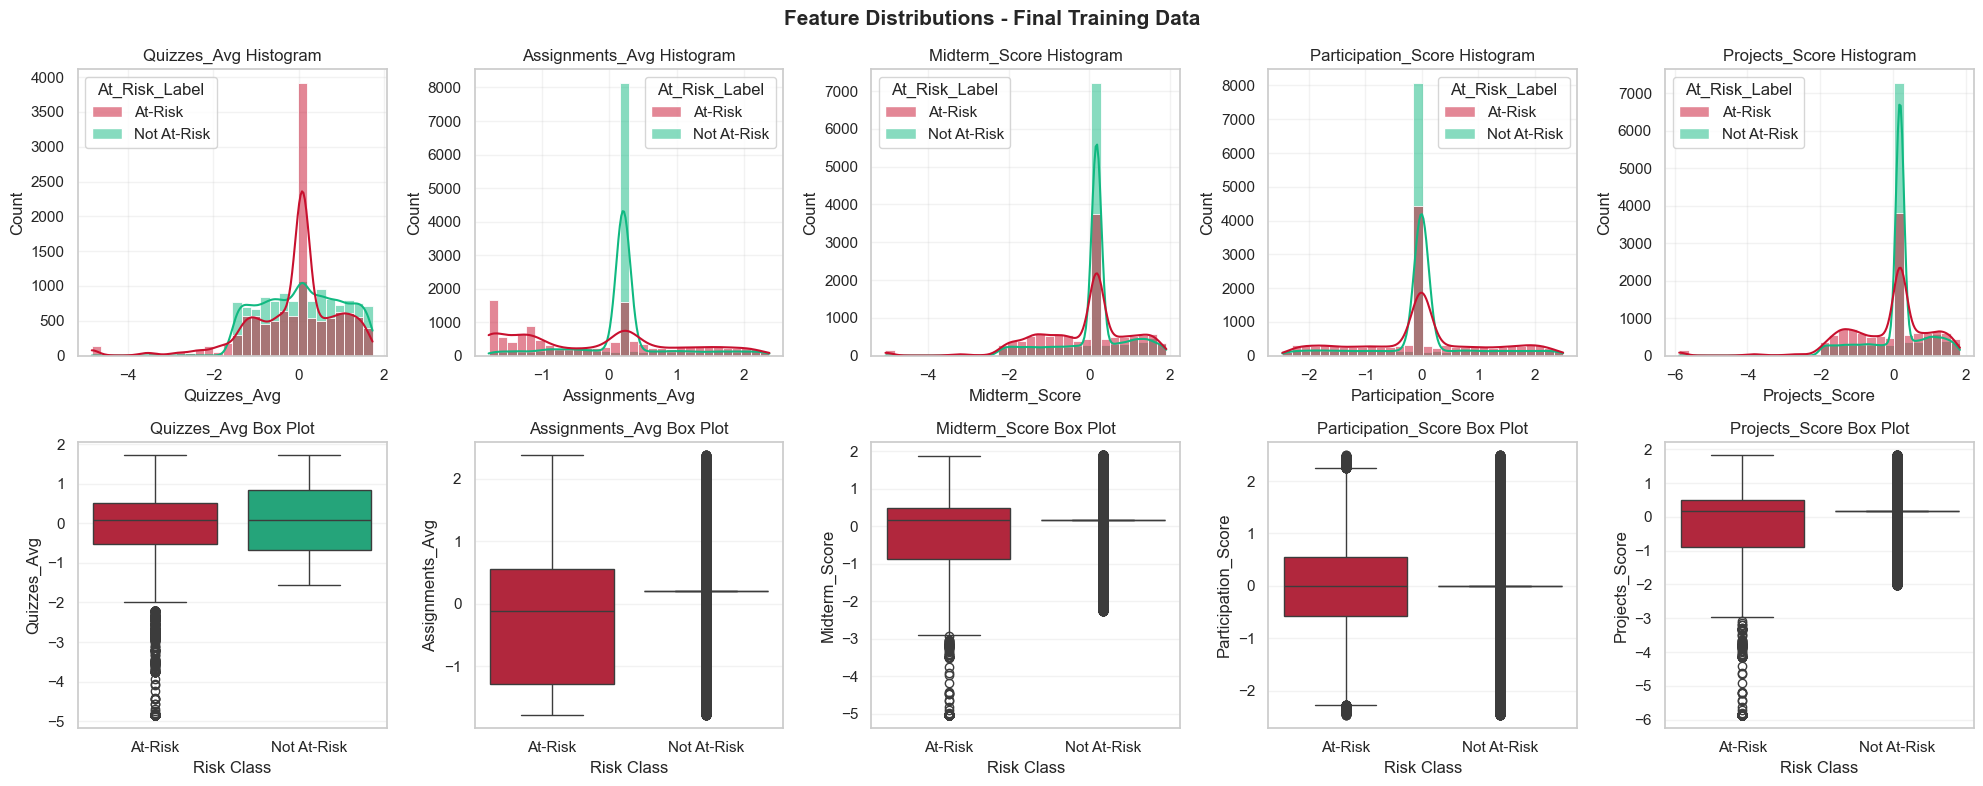

In [8]:
if TRAIN_FILE.exists():
    df_train = pd.read_csv(TRAIN_FILE)

    # Ensure target column is numeric
    df_train[TARGET_COL] = pd.to_numeric(df_train[TARGET_COL], errors="coerce")

    # Create clean labels for plotting
    df_train["At_Risk_Label"] = df_train[TARGET_COL].map({
        0: "Not At-Risk",
        1: "At-Risk"
    })

    fig, axes = plt.subplots(2, len(FINAL_FEATURES), figsize=(20, 8))
    fig.suptitle("Feature Distributions - Final Training Data", fontsize=15, fontweight="bold")

    for i, feat in enumerate(FINAL_FEATURES):
        if feat not in df_train.columns:
            continue

        plot_df = df_train[[feat, "At_Risk_Label"]].dropna().copy()

        sns.histplot(
            data=plot_df,
            x=feat,
            hue="At_Risk_Label",
            stat="count",
            bins=30,
            kde=True,
            ax=axes[0, i],
            palette={
                "Not At-Risk": COLORS["low"],
                "At-Risk": COLORS["high"]
            }
        )
        axes[0, i].set_title(f"{feat} Histogram")
        axes[0, i].set_xlabel(feat)

        sns.boxplot(
            data=plot_df,
            x="At_Risk_Label",
            y=feat,
            ax=axes[1, i],
            palette={
                "Not At-Risk": COLORS["low"],
                "At-Risk": COLORS["high"]
            }
        )
        axes[1, i].set_title(f"{feat} Box Plot")
        axes[1, i].set_xlabel("Risk Class")

    plt.tight_layout()
    plt.show()
else:
    print("[SKIP] ds1_train_smote.csv not found.")

## 8. Missing Values and Feature Coverage

,Missing_%
Quizzes_Avg,0.0
Assignments_Avg,0.0
Midterm_Score,0.0
Participation_Score,0.0
Projects_Score,0.0


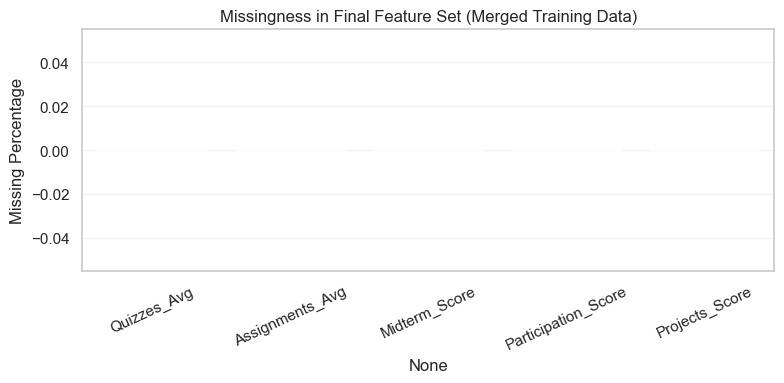

,Quizzes_Avg,Assignments_Avg,Midterm_Score,Participation_Score,Projects_Score
source,,,,,
DS1,100.0,100.0,100.0,100.0,100.0
DS2,100.0,100.0,100.0,100.0,100.0
DS3,100.0,100.0,100.0,100.0,100.0
DS4,100.0,100.0,100.0,100.0,100.0


In [9]:

if MERGED_FILE.exists():
    df_merged = pd.read_csv(MERGED_FILE)

    missing_pct = df_merged[FINAL_FEATURES].isna().mean().sort_values(ascending=False) * 100
    display(missing_pct.to_frame("Missing_%"))

    plt.figure(figsize=(8, 4))
    sns.barplot(x=missing_pct.index, y=missing_pct.values)
    plt.title("Missingness in Final Feature Set (Merged Training Data)")
    plt.ylabel("Missing Percentage")
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()

    if "source" in df_merged.columns:
        coverage = (
            df_merged.groupby("source")[FINAL_FEATURES]
            .apply(lambda x: x.notna().mean() * 100)
            .round(2)
        )
        display(coverage)
else:
    print("[SKIP] merged_training_data.csv not found.")


## 9. Correlation Analysis

,Quizzes_Avg,Assignments_Avg,Midterm_Score,Participation_Score,Projects_Score,At_Risk
Quizzes_Avg,1.000000,0.003018,0.096949,-0.003344,0.128212,-0.050696
Assignments_Avg,0.003018,1.000000,-0.024484,0.012752,-0.012241,-0.164398
Midterm_Score,0.096949,-0.024484,1.000000,-0.002394,0.255380,-0.098545
Participation_Score,-0.003344,0.012752,-0.002394,1.000000,-0.023739,-0.004187
Projects_Score,0.128212,-0.012241,0.255380,-0.023739,1.000000,-0.112376
At_Risk,-0.050696,-0.164398,-0.098545,-0.004187,-0.112376,1.000000


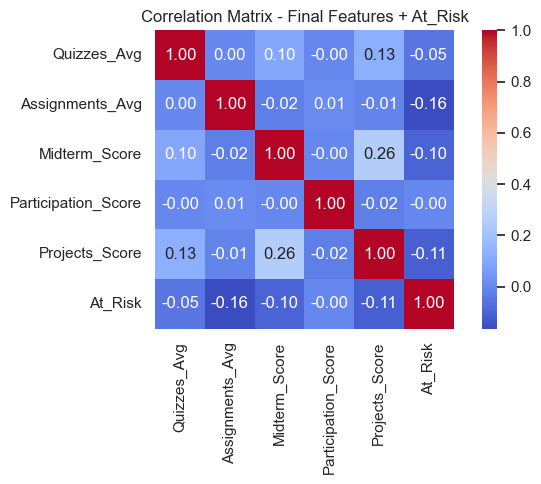

Correlation with At_Risk:
  Quizzes_Avg            -0.0507
  Assignments_Avg        -0.1644
  Midterm_Score          -0.0985
  Participation_Score    -0.0042
  Projects_Score         -0.1124


In [10]:

if MERGED_FILE.exists():
    df_merged = pd.read_csv(MERGED_FILE)
    corr_cols = [c for c in FINAL_FEATURES + [TARGET_COL] if c in df_merged.columns]
    corr = df_merged[corr_cols].corr()

    display(corr)

    plt.figure(figsize=(7, 5))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
    plt.title("Correlation Matrix - Final Features + At_Risk")
    plt.tight_layout()
    plt.show()

    print("Correlation with At_Risk:")
    for feat in FINAL_FEATURES:
        if feat in corr.index:
            print(f"  {feat:<22} {corr.loc[feat, TARGET_COL]: .4f}")
else:
    print("[SKIP] merged_training_data.csv not found.")


## 10. Cross-Dataset Comparison

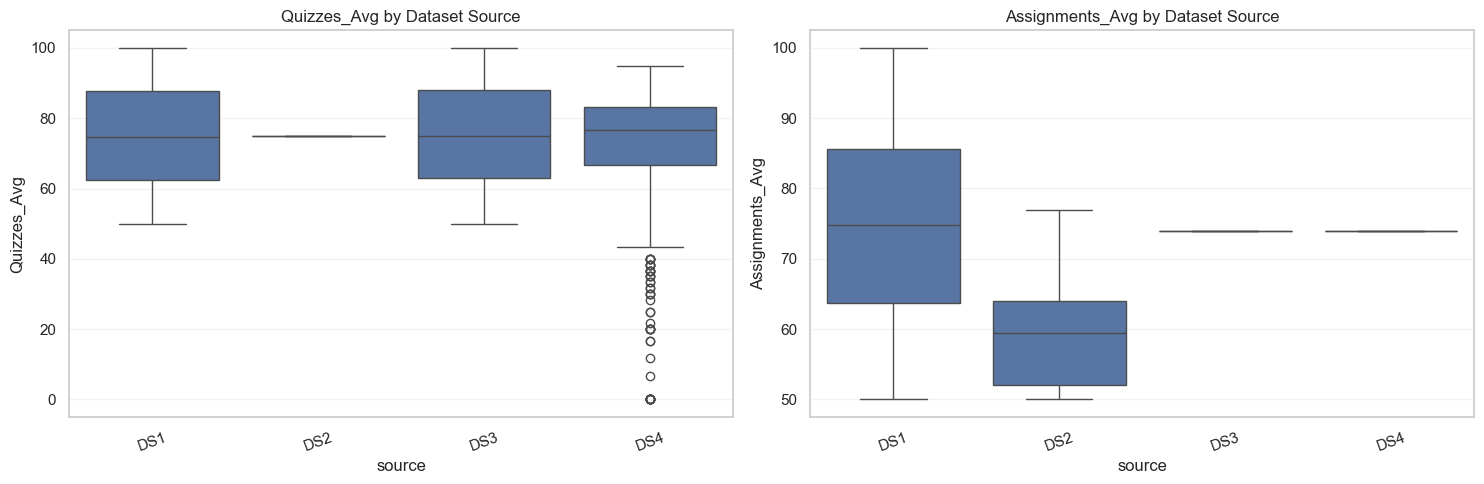

,source,records
0,DS3,6607
1,DS1,5000
2,DS4,1053
3,DS2,708


In [11]:

if MERGED_FILE.exists():
    df_merged = pd.read_csv(MERGED_FILE)

    if "source" in df_merged.columns:
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        sns.boxplot(data=df_merged, x="source", y="Quizzes_Avg", ax=axes[0])
        axes[0].set_title("Quizzes_Avg by Dataset Source")
        axes[0].tick_params(axis="x", rotation=20)

        sns.boxplot(data=df_merged, x="source", y="Assignments_Avg", ax=axes[1])
        axes[1].set_title("Assignments_Avg by Dataset Source")
        axes[1].tick_params(axis="x", rotation=20)

        plt.tight_layout()
        plt.show()

        source_counts = df_merged["source"].value_counts().rename_axis("source").reset_index(name="records")
        display(source_counts)
    else:
        print("No 'source' column available in merged data.")
else:
    print("[SKIP] merged_training_data.csv not found.")



## 11. Saved Model Metrics

This section reads the metrics generated by the current `src/train_model.py` pipeline from:

- `models/model_metrics.json`

It summarises the comparison between:
- Logistic Regression
- Random Forest
- XGBoost


In [12]:

if MODEL_METRICS.exists():
    with open(MODEL_METRICS, "r", encoding="utf-8") as f:
        metrics = json.load(f)

    meta_keys = {"best_model", "ml_threshold", "features_used", "oulad_warning"}
    model_names = [k for k in metrics.keys() if k not in meta_keys]

    rows = []
    for model_name in model_names:
        test_metrics = metrics[model_name].get("test", {})
        rows.append({
            "Model": model_name,
            "Accuracy": test_metrics.get("accuracy"),
            "Precision": test_metrics.get("precision"),
            "Recall": test_metrics.get("recall"),
            "F1": test_metrics.get("f1"),
            "ROC_AUC": test_metrics.get("roc_auc"),
        })

    metrics_df = pd.DataFrame(rows).sort_values("F1", ascending=False)
    display(metrics_df)

    print("Best model:", metrics.get("best_model"))
    print("ML threshold:", metrics.get("ml_threshold"))
    print("Features used:", metrics.get("features_used"))
else:
    print("[SKIP] model_metrics.json not found.")


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
1,Random Forest,0.9224,0.8705,0.9926,0.9275,0.9876
2,XGBoost,0.8933,0.8386,0.9739,0.9012,0.9628
0,Logistic Regression,0.5846,0.5669,0.7170,0.6332,0.6842


Best model: Random Forest
ML threshold: 0.45
Features used: ['Quizzes_Avg', 'Assignments_Avg', 'Midterm_Score', 'Participation_Score', 'Projects_Score']


## 12. Model Comparison Plot

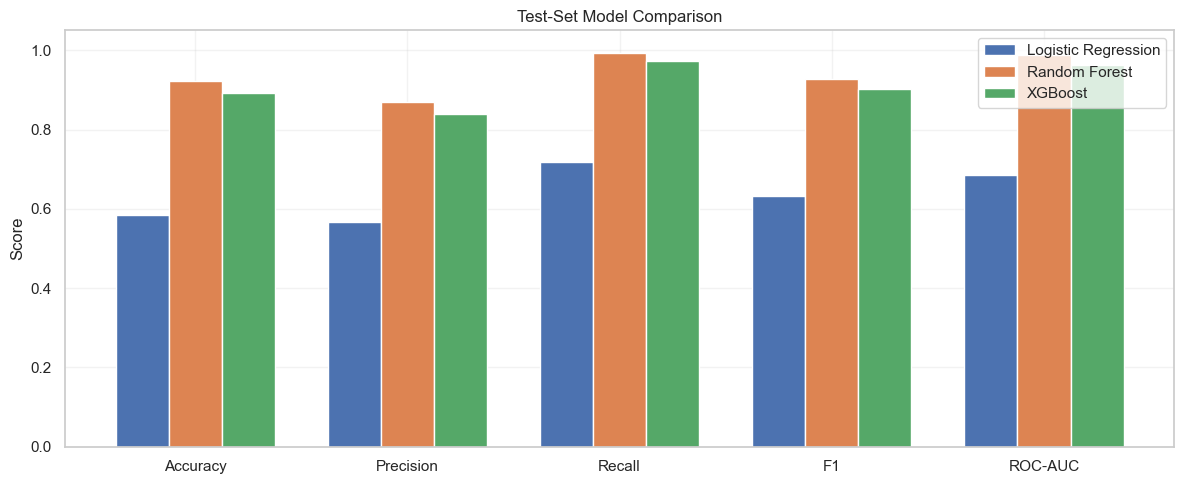

In [13]:

if MODEL_METRICS.exists():
    with open(MODEL_METRICS, "r", encoding="utf-8") as f:
        metrics = json.load(f)

    meta_keys = {"best_model", "ml_threshold", "features_used", "oulad_warning"}
    model_names = [k for k in metrics.keys() if k not in meta_keys]

    metric_keys = ["accuracy", "precision", "recall", "f1", "roc_auc"]
    x = np.arange(len(metric_keys))
    width = 0.25

    plt.figure(figsize=(12, 5))
    for i, model_name in enumerate(model_names):
        vals = [metrics[model_name]["test"].get(m, np.nan) for m in metric_keys]
        plt.bar(x + i * width, vals, width=width, label=model_name)

    plt.xticks(x + width, ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"])
    plt.ylim(0, 1.05)
    plt.ylabel("Score")
    plt.title("Test-Set Model Comparison")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("[SKIP] model_metrics.json not found.")


## 13. Threshold Sensitivity and Evaluation Plots

Available evaluation plots:
 - confusion_matrices.png
 - roc_curves.png
 - feature_importance.png
 - threshold_analysis.png
 - correlation_heatmap.png
 - learning_curve.png
 - metrics_table.png


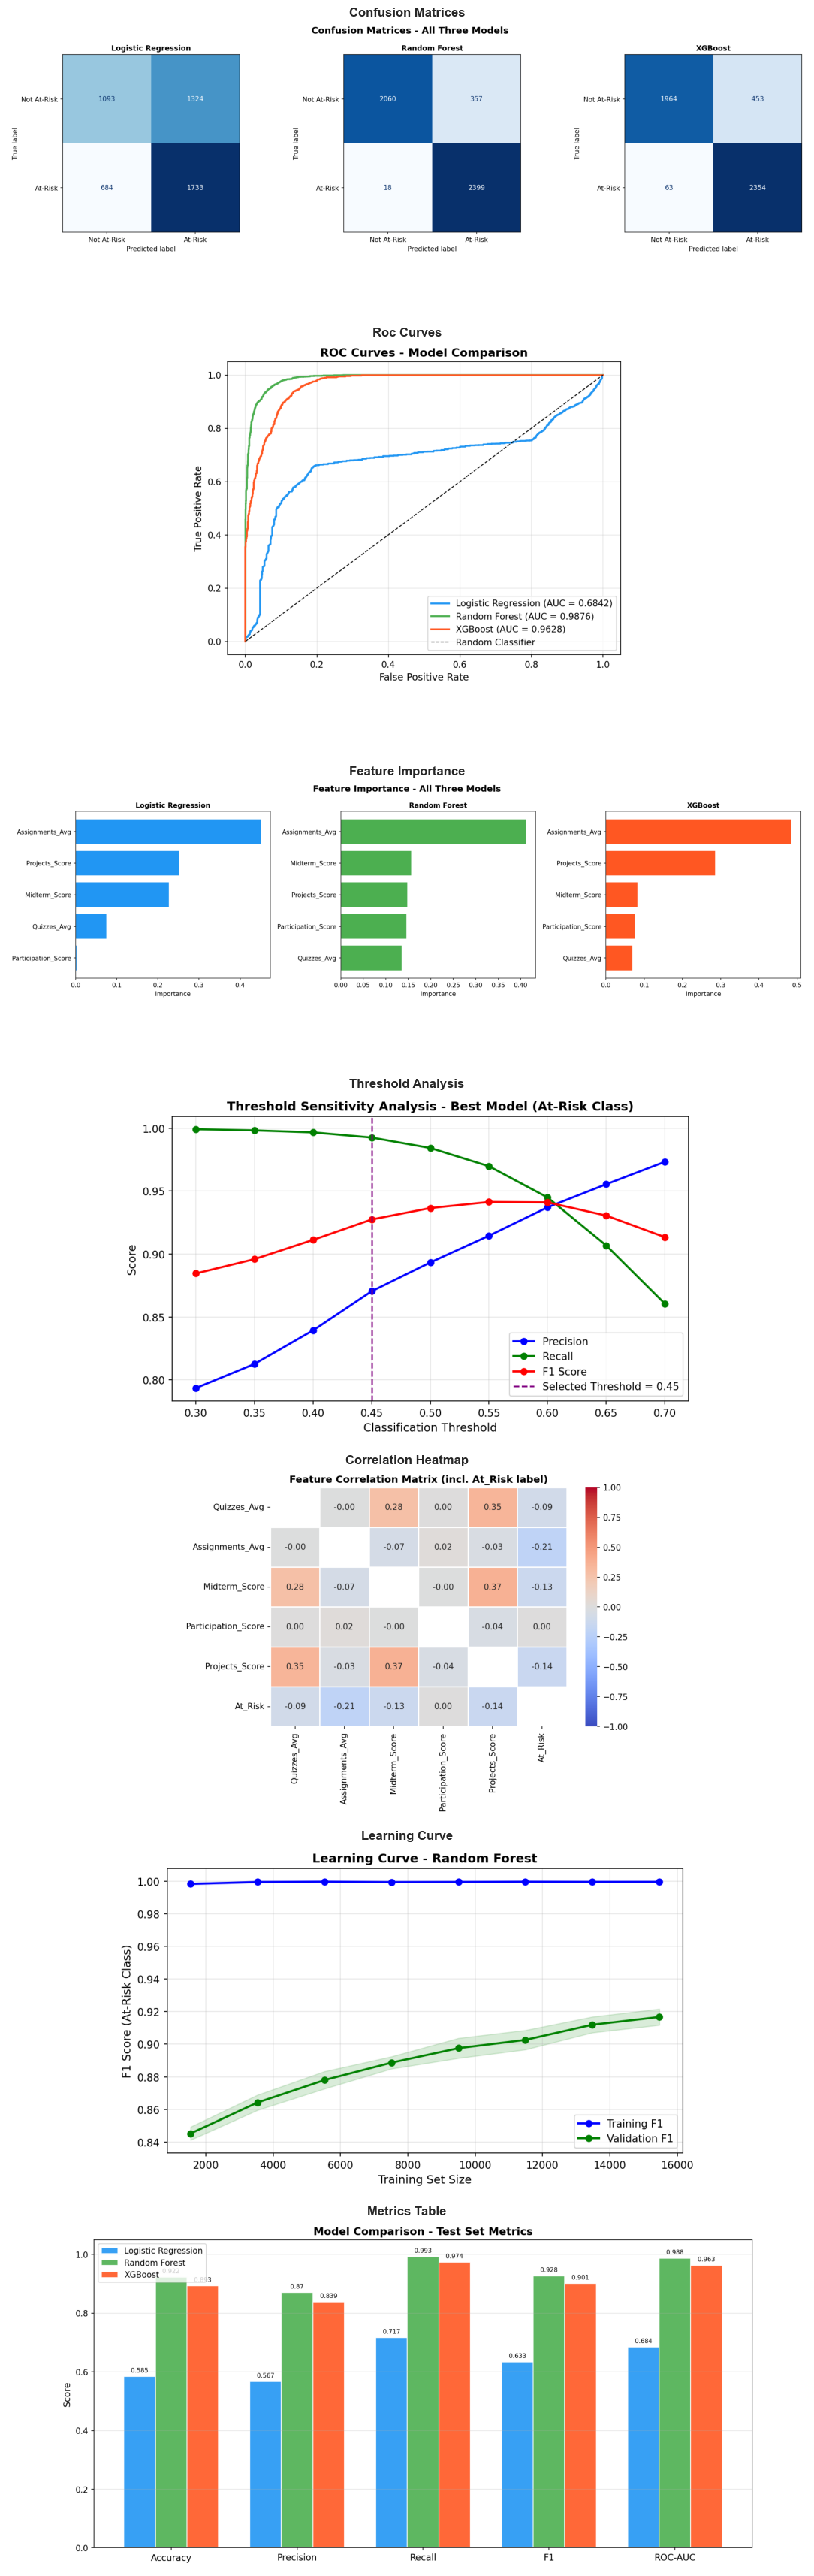

In [14]:

plot_files = [
    "confusion_matrices.png",
    "roc_curves.png",
    "feature_importance.png",
    "threshold_analysis.png",
    "correlation_heatmap.png",
    "learning_curve.png",
    "metrics_table.png",
]

existing = []
for pf in plot_files:
    p = PLOTS_DIR / pf
    if p.exists():
        existing.append(p)

if existing:
    print("Available evaluation plots:")
    for p in existing:
        print(" -", p.name)

    fig, axes = plt.subplots(len(existing), 1, figsize=(11, 5 * len(existing)))
    if len(existing) == 1:
        axes = [axes]

    for ax, p in zip(axes, existing):
        img = plt.imread(p)
        ax.imshow(img)
        ax.set_title(p.name.replace("_", " ").replace(".png", "").title(), fontsize=12, fontweight="bold")
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("[SKIP] No evaluation plots found in reports/plots/. Run src/evaluate_model.py first.")


## 14. Final Model Selection Summary

In [15]:

if MODEL_METRICS.exists():
    with open(MODEL_METRICS, "r", encoding="utf-8") as f:
        metrics = json.load(f)

    best_model = metrics.get("best_model", "Unknown")
    threshold = metrics.get("ml_threshold", "Unknown")
    features = metrics.get("features_used", [])

    print("=" * 78)
    print("FINAL MODEL SELECTION SUMMARY")
    print("=" * 78)

    meta_keys = {"best_model", "ml_threshold", "features_used", "oulad_warning"}
    for model_name, block in metrics.items():
        if model_name in meta_keys:
            continue
        test = block.get("test", {})
        marker = "  <-- SELECTED" if model_name == best_model else ""
        print(
            f"{model_name:<22} "
            f"Accuracy={test.get('accuracy', 'NA')}  "
            f"Precision={test.get('precision', 'NA')}  "
            f"Recall={test.get('recall', 'NA')}  "
            f"F1={test.get('f1', 'NA')}  "
            f"ROC_AUC={test.get('roc_auc', 'NA')}{marker}"
        )

    print("\nSelected model:", best_model)
    print("Selected threshold:", threshold)
    print("Final features:", features)

    print("\nWhy this selection is justified:")
    print("- The chosen model maximises F1 on the at-risk class.")
    print("- Recall remains a high-priority metric because missing an at-risk student is costly.")
    print("- The selected feature set avoids direct leakage from final outcomes.")
    print("- The hybrid system preserves interpretability by combining ML with deterministic logic.")
else:
    print("[SKIP] model_metrics.json not found.")


FINAL MODEL SELECTION SUMMARY
Logistic Regression    Accuracy=0.5846  Precision=0.5669  Recall=0.717  F1=0.6332  ROC_AUC=0.6842
Random Forest          Accuracy=0.9224  Precision=0.8705  Recall=0.9926  F1=0.9275  ROC_AUC=0.9876  <-- SELECTED
XGBoost                Accuracy=0.8933  Precision=0.8386  Recall=0.9739  F1=0.9012  ROC_AUC=0.9628

Selected model: Random Forest
Selected threshold: 0.45
Final features: ['Quizzes_Avg', 'Assignments_Avg', 'Midterm_Score', 'Participation_Score', 'Projects_Score']

Why this selection is justified:
- The chosen model maximises F1 on the at-risk class.
- Recall remains a high-priority metric because missing an at-risk student is costly.
- The selected feature set avoids direct leakage from final outcomes.
- The hybrid system preserves interpretability by combining ML with deterministic logic.


In [16]:
print("FINAL PIPELINE SUMMARY")
print("-" * 60)
print("Merged training pool : 13,368")
print("After SMOTE          : 24,170")
print("Train split          : 19,336")
print("Test split           : 4,834")
print("Best model           : Random Forest")
print("Threshold            : 0.45")
print("Features             :", FINAL_FEATURES)

FINAL PIPELINE SUMMARY
------------------------------------------------------------
Merged training pool : 13,368
After SMOTE          : 24,170
Train split          : 19,336
Test split           : 4,834
Best model           : Random Forest
Threshold            : 0.45
Features             : ['Quizzes_Avg', 'Assignments_Avg', 'Midterm_Score', 'Participation_Score', 'Projects_Score']


## Final Analytical Summary

The latest pipeline results show that:

- Datasets 1–4 were merged into a unified training pool of **13,368 records**
- The minority at-risk class was corrected using **SMOTE**, producing a balanced training dataset of **24,170 records**
- The balanced dataset was split into:
  - **19,336 training records**
  - **4,834 test records**
- The final selected feature set was:
  - `Quizzes_Avg`
  - `Assignments_Avg`
  - `Midterm_Score`
  - `Participation_Score`
  - `Projects_Score`
- The best-performing model was **Random Forest**
- The selected classification threshold was **0.45**
- Model selection was based on **F1-score for the at-risk class**, because missing at-risk students is more harmful than occasional false alarms
- The deployed system uses a **hybrid design**, combining:
  - ML probability from the selected model
  - deterministic risk logic from quiz trends and assignment performance

### Important limitation
The OULAD validation set does not contain all final live-system features.  
`Midterm_Score`, `Participation_Score`, and `Projects_Score` are filled with neutral placeholder values during validation, so OULAD validation F1/Recall should be interpreted cautiously.